# Численное решение уравнения теплопроводности с использованием разностных схем расщепления

## Введение

В данной практической работе рассматривается численное решение двумерного уравнения теплопроводности (теплопереноса) с помощью разностных схем расщепления. Уравнение теплопроводности является одним из фундаментальных уравнений математической физики и описывает процесс распространения тепла в среде.

### Цели работы:
1. Реализовать различные разностные схемы расщепления для решения уравнения теплопроводности
2. Сравнить результаты, полученные различными схемами
3. Исследовать сходимость численного решения по сетке
4. Визуализировать процесс распространения тепла с использованием цветовой кодировки

## Постановка задачи

Решить уравнение теплопроводности:

$$\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}, \quad 0 \leq x \leq 1, \quad 0 \leq y \leq 1$$

С начальными и граничными условиями:
- $u(0, x, y) = 0$ - начальное условие
- $u(t, 0, y) = 0$ - левая граница
- $u(t, 1, y) = 1$ - правая граница
- $u(t, x, 0) = 2$ - нижняя граница
- $u(t, x, 1) = 3$ - верхняя граница

Использовать разностные схемы расщепления:

**а)** Схема (П2.20):
$$\frac{\tilde{u}_{ml} - u^n_{ml}}{\tau} = \Lambda_1 \tilde{u}_{ml}, \quad \frac{u^{n+1}_{ml} - \tilde{u}_{ml}}{\tau} = \Lambda_2 u^{n+1}_{ml}$$

**б)** Схема (П2.21) при $\xi = 1/2$:
$$\frac{u^{n+1/2}_{ml} - u^n_{ml}}{\tau} = \Lambda_1 \left[\xi u^{n+1/2}_{ml} + (1-\xi)u^n_{ml}\right]$$
$$\frac{u^{n+1}_{ml} - u^{n+1/2}_{ml}}{\tau} = \Lambda_2 \left[\xi u^{n+1}_{ml} + (1-\xi)u^{n+1/2}_{ml}\right]$$

**в)** Схема (П2.22):
$$\frac{\tilde{u}_{ml} - u^n_{ml}}{\tau} = \frac{1}{2}\left(\Lambda_1 \tilde{u}_{ml} + \Lambda_2 u^n_{ml}\right)$$
$$\frac{u^{n+1}_{ml} - u^{n+1/2}_{ml}}{\tau} = \frac{1}{2}\left(\Lambda_1 \tilde{u}_{ml} + \Lambda_2 u^{n+1}_{ml}\right)$$

**г)** Схема (П2.23):
$$\frac{\tilde{u}_{ml} - u^n_{ml}}{\tau} = \Lambda_1 u^n_{ml}, \quad \frac{u^{n+1}_{ml} - \tilde{u}_{ml}}{\tau} = \Lambda_2 \tilde{u}_{ml}$$

где разностные операторы:
$$\Lambda_1 u^{n+1}_{ml} = \frac{u^{n+1}_{m-1,l} - 2u^{n+1}_{m,l} + u^{n+1}_{m+1,l}}{h_x^2}$$
$$\Lambda_2 u^{n+1}_{ml} = \frac{u^{n+1}_{m,l-1} - 2u^{n+1}_{m,l} + u^{n+1}_{m,l+1}}{h_y^2}$$

## Импорт необходимых библиотек

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
import time
from scipy import linalg

## Реализация разностных схем расщепления

In [16]:
class HeatEquationSolver:
    """
    Класс для решения двумерного уравнения теплопроводности
    различными разностными схемами расщепления
    """

    def __init__(self, nx=20, ny=20, t_max=0.1,
                 x_min=0, x_max=1, y_min=0, y_max=1):
        """
        Инициализация решателя

        Параметры:
        nx, ny - количество узлов сетки по x и y
        t_max - максимальное время моделирования
        x_min, x_max - границы по x
        y_min, y_max - границы по y
        """
        self.nx = nx
        self.ny = ny
        self.t_max = t_max
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max

        self.hx = (x_max - x_min) / (nx - 1)
        self.hy = (y_max - y_min) / (ny - 1)

        self.tau = 0.5 * min(self.hx**2, self.hy**2)

        self.x = np.linspace(x_min, x_max, nx)
        self.y = np.linspace(y_min, y_max, ny)
        self.X, self.Y = np.meshgrid(self.x, self.y)

        self.nt = int(t_max / self.tau) + 1

        self.rx = self.tau / self.hx**2
        self.ry = self.tau / self.hy**2

        self.u = np.zeros((nx, ny))

    def set_initial_condition(self, u_init=None):
        """Установка начального условия"""
        if u_init is not None:
            self.u = u_init.copy()
        else:
            self.u = np.zeros((self.nx, self.ny))

    def set_boundary_conditions(self, u):
        """
        Установка граничных условий
        u(t, 0, y) = 0
        u(t, 1, y) = 1
        u(t, x, 0) = 2
        u(t, x, 1) = 3
        """
        u[0, :] = 0      # Левая граница
        u[-1, :] = 1     # Правая граница
        u[:, 0] = 2      # Нижняя граница
        u[:, -1] = 3     # Верхняя граница
        return u

    def solve_tridiagonal(self, a, b, c, d):
        """
        Решение трехдиагональной системы методом прогонки
        a - нижняя диагональ
        b - главная диагональ
        c - верхняя диагональ
        d - правая часть
        """
        n = len(d)
        alpha = np.zeros(n)
        beta = np.zeros(n)
        x = np.zeros(n)

        alpha[0] = -c[0] / b[0]
        beta[0] = d[0] / b[0]

        for i in range(1, n):
            denom = b[i] + a[i] * alpha[i-1]
            alpha[i] = -c[i] / denom if i < n-1 else 0
            beta[i] = (d[i] - a[i] * beta[i-1]) / denom

        x[-1] = beta[-1]
        for i in range(n-2, -1, -1):
            x[i] = alpha[i] * x[i+1] + beta[i]

        return x

    def scheme_a(self, verbose=True):
        """
        Схема (а) - (П2.20): Простое расщепление
        Первая дробь: явная по x
        Вторая дробь: неявная по y
        """
        if verbose:
            print("Схема (а) - простое расщепление (П2.20)")
            print(f"Шаги: hx={self.hx:.4f}, hy={self.hy:.4f}, tau={self.tau:.6f}")

        u = self.u.copy()
        u = self.set_boundary_conditions(u)


        a_y = -self.ry * np.ones(self.ny)
        b_y = (1 + 2*self.ry) * np.ones(self.ny)
        c_y = -self.ry * np.ones(self.ny)

        history = []

        for n in range(self.nt):
            u_old = u.copy()

            u_tilde = u_old.copy()
            for i in range(1, self.nx-1):
                for j in range(1, self.ny-1):
                    u_tilde[i, j] = u_old[i, j] + self.rx * (
                        u_old[i-1, j] - 2*u_old[i, j] + u_old[i+1, j]
                    )

            u_new = u_tilde.copy()
            for i in range(1, self.nx-1):
                rhs = u_tilde[i, 1:self.ny-1]
                rhs[0] += self.ry * u_new[i, 0]
                rhs[-1] += self.ry * u_new[i, self.ny-1]

                u_new[i, 1:self.ny-1] = self.solve_tridiagonal(
                    a_y, b_y, c_y, rhs
                )

            u = self.set_boundary_conditions(u_new)

            if n % max(1, self.nt // 10) == 0:
                history.append(u.copy())

        return u, history

    def scheme_b(self, xi=0.5, verbose=True):
        """
        Схема (б) - (П2.21): Взвешенное расщепление
        При xi = 0.5 - схема Кранка-Николсон
        """
        if verbose:
            print(f"Схема (б) - взвешенное расщепление (П2.21), xi={xi}")
            print(f"Шаги: hx={self.hx:.4f}, hy={self.hy:.4f}, tau={self.tau:.6f}")

        u = self.u.copy()
        u = self.set_boundary_conditions(u)

        a_x = -xi * self.rx * np.ones(self.nx)
        b_x = (1 + 2*xi*self.rx) * np.ones(self.nx)
        c_x = -xi * self.rx * np.ones(self.nx)

        a_y = -xi * self.ry * np.ones(self.ny)
        b_y = (1 + 2*xi*self.ry) * np.ones(self.ny)
        c_y = -xi * self.ry * np.ones(self.ny)

        history = []

        for n in range(self.nt):
            u_old = u.copy()

            u_half = u_old.copy()
            for j in range(1, self.ny-1):
                rhs = np.zeros(self.nx)
                for i in range(1, self.nx-1):
                    rhs[i] = u_old[i, j] + (1-xi)*self.rx * (
                        u_old[i-1, j] - 2*u_old[i, j] + u_old[i+1, j]
                    )

                rhs[0] = 0
                rhs[-1] = 1

                u_half[1:self.nx-1, j] = self.solve_tridiagonal(
                    a_x[1:self.nx-1], b_x[1:self.nx-1],
                    c_x[1:self.nx-1], rhs[1:self.nx-1]
                )

            u_half = self.set_boundary_conditions(u_half)

            u_new = u_half.copy()
            for i in range(1, self.nx-1):
                rhs = np.zeros(self.ny)
                for j in range(1, self.ny-1):
                    rhs[j] = u_half[i, j] + (1-xi)*self.ry * (
                        u_half[i, j-1] - 2*u_half[i, j] + u_half[i, j+1]
                    )

                rhs[0] = 2
                rhs[-1] = 3

                u_new[i, 1:self.ny-1] = self.solve_tridiagonal(
                    a_y[1:self.ny-1], b_y[1:self.ny-1],
                    c_y[1:self.ny-1], rhs[1:self.ny-1]
                )

            u = self.set_boundary_conditions(u_new)

            if n % max(1, self.nt // 10) == 0:
                history.append(u.copy())

        return u, history

    def scheme_c(self, verbose=True):
        """
        Схема (в) - (П2.22): Симметричное расщепление
        """
        if verbose:
            print("Схема (в) - симметричное расщепление (П2.22)")
            print(f"Шаги: hx={self.hx:.4f}, hy={self.hy:.4f}, tau={self.tau:.6f}")

        u = self.u.copy()
        u = self.set_boundary_conditions(u)

        a_x = -0.5 * self.rx * np.ones(self.nx)
        b_x = (1 + self.rx) * np.ones(self.nx)
        c_x = -0.5 * self.rx * np.ones(self.nx)

        a_y = -0.5 * self.ry * np.ones(self.ny)
        b_y = (1 + self.ry) * np.ones(self.ny)
        c_y = -0.5 * self.ry * np.ones(self.ny)

        history = []

        for n in range(self.nt):
            u_old = u.copy()

            u_tilde = u_old.copy()
            for j in range(1, self.ny-1):
                rhs = np.zeros(self.nx)
                for i in range(1, self.nx-1):
                    rhs[i] = u_old[i, j] + 0.5*self.rx * (
                        u_old[i-1, j] - 2*u_old[i, j] + u_old[i+1, j]
                    ) + 0.5*self.ry * (
                        u_old[i, max(0,j-1)] - 2*u_old[i, j] + u_old[i, min(self.ny-1,j+1)]
                    )

                rhs[0] = 0
                rhs[-1] = 1

                u_tilde[1:self.nx-1, j] = self.solve_tridiagonal(
                    a_x[1:self.nx-1], b_x[1:self.nx-1],
                    c_x[1:self.nx-1], rhs[1:self.nx-1]
                )

            u_tilde = self.set_boundary_conditions(u_tilde)

            u_new = u_tilde.copy()
            for i in range(1, self.nx-1):
                rhs = np.zeros(self.ny)
                for j in range(1, self.ny-1):
                    rhs[j] = u_tilde[i, j] + 0.5*self.rx * (
                        u_tilde[max(0,i-1), j] - 2*u_tilde[i, j] + u_tilde[min(self.nx-1,i+1), j]
                    ) + 0.5*self.ry * (
                        u_tilde[i, j-1] - 2*u_tilde[i, j] + u_tilde[i, j+1]
                    )

                rhs[0] = 2
                rhs[-1] = 3

                u_new[i, 1:self.ny-1] = self.solve_tridiagonal(
                    a_y[1:self.ny-1], b_y[1:self.ny-1],
                    c_y[1:self.ny-1], rhs[1:self.ny-1]
                )

            u = self.set_boundary_conditions(u_new)

            if n % max(1, self.nt // 10) == 0:
                history.append(u.copy())

        return u, history

    def scheme_d(self, verbose=True):
        """
        Схема (г) - (П2.23): Явно-неявное расщепление
        """
        if verbose:
            print("Схема (г) - явно-неявное расщепление (П2.23)")
            print(f"Шаги: hx={self.hx:.4f}, hy={self.hy:.4f}, tau={self.tau:.6f}")

        u = self.u.copy()
        u = self.set_boundary_conditions(u)

        history = []

        for n in range(self.nt):
            u_old = u.copy()

            u_tilde = u_old.copy()
            for i in range(1, self.nx-1):
                for j in range(1, self.ny-1):
                    u_tilde[i, j] = u_old[i, j] + self.rx * (
                        u_old[i-1, j] - 2*u_old[i, j] + u_old[i+1, j]
                    )

            u_new = u_tilde.copy()
            for i in range(1, self.nx-1):
                for j in range(1, self.ny-1):
                    u_new[i, j] = u_tilde[i, j] + self.ry * (
                        u_tilde[i, j-1] - 2*u_tilde[i, j] + u_tilde[i, j+1]
                    )

            u = self.set_boundary_conditions(u_new)

            if n % max(1, self.nt // 10) == 0:
                history.append(u.copy())

        return u, history

    def reset(self):
        """Сброс решения к начальному условию"""
        self.u = np.zeros((self.nx, self.ny))

## Функции визуализации

In [17]:
def plot_temperature_distribution(solver, u, title="Распределение температуры",
                                   show_colorbar=True, ax=None):
    """
    Визуализация распределения температуры
    с использованием цветовой карты
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    colors = [
        '#00008B',  # Темно-синий
        '#0000FF',  # Синий
        '#00FFFF',  # Голубой
        '#00FF00',  # Зеленый
        '#FFFF00',  # Желтый
        '#FFA500',  # Оранжевый
        '#FF0000',  # Красный
        '#8B0000'   # Темно-красный
    ]

    cmap = LinearSegmentedColormap.from_list('temperature', colors, N=256)

    im = ax.imshow(u.T, origin='lower', extent=[0, 1, 0, 1],
                   cmap=cmap, vmin=0, vmax=3, aspect='equal')

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Температура')
        cbar.set_ticks([0, 1, 2, 3])
        cbar.set_ticklabels(['0 (левая)', '1 (правая)', '2 (нижняя)', '3 (верхняя)'])

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title, fontsize=12, pad=20)

    return ax, im


def plot_3d_surface(solver, u, title="3D распределение температуры"):
    """Визуализация в виде 3D поверхности"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')


    colors = [
        '#00008B', '#0000FF', '#00FFFF', '#00FF00',
        '#FFFF00', '#FFA500', '#FF0000', '#8B0000'
    ]
    cmap = LinearSegmentedColormap.from_list('temperature', colors, N=256)

    surf = ax.plot_surface(solver.X, solver.Y, u.T, cmap=cmap,
                          vmin=0, vmax=3, linewidth=0, antialiased=True,
                          alpha=0.9)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('Температура u')
    ax.set_title(title, pad=20)

    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    cbar.set_label('Температура')

    return fig, ax


def plot_comparison(solvers_results, titles, t_max):
    """
    Сравнение результатов различных схем
    """
    n_schemes = len(solvers_results)
    fig, axes = plt.subplots(2, n_schemes, figsize=(5*n_schemes, 8))

    if n_schemes == 1:
        axes = axes.reshape(-1, 1)

    colors = [
        '#00008B', '#0000FF', '#00FFFF', '#00FF00',
        '#FFFF00', '#FFA500', '#FF0000', '#8B0000'
    ]
    cmap = LinearSegmentedColormap.from_list('temperature', colors, N=256)

    for idx, (u, history) in enumerate(solvers_results):

        im1 = axes[0, idx].imshow(u.T, origin='lower', extent=[0, 1, 0, 1],
                                  cmap=cmap, vmin=0, vmax=3, aspect='equal')
        axes[0, idx].set_xlabel('x')
        axes[0, idx].set_ylabel('y')
        axes[0, idx].set_title(f'{titles[idx]}\n(2D распределение)')
        plt.colorbar(im1, ax=axes[0, idx], label='Температура')


        nx, ny = u.shape
        mid_x = nx // 2
        mid_y = ny // 2

        x_vals = np.linspace(0, 1, nx)
        y_vals = np.linspace(0, 1, ny)

        axes[1, idx].plot(x_vals, u[:, mid_y], 'b-', linewidth=2, label=f'y = {y_vals[mid_y]:.2f}')
        axes[1, idx].plot(x_vals, u[:, 1], 'r--', linewidth=2, label=f'y = {y_vals[1]:.2f}')
        axes[1, idx].plot(x_vals, u[:, -2], 'g-.', linewidth=2, label=f'y = {y_vals[-2]:.2f}')
        axes[1, idx].set_xlabel('x')
        axes[1, idx].set_ylabel('Температура')
        axes[1, idx].set_title(f'Сечения по x (t = {t_max:.3f})')
        axes[1, idx].legend(fontsize=8)
        axes[1, idx].grid(True, alpha=0.3)
        axes[1, idx].set_ylim(0, 3.5)

    plt.tight_layout()
    return fig, axes

## Основная программа: решение и анализ

In [18]:
nx = 41
ny = 41
t_max = 0.05

print("="*70)
print("РЕШЕНИЕ УРАВНЕНИЯ ТЕПЛОПРОВОДНОСТИ")
print("="*70)
print(f"\nПараметры сетки:")
print(f"  Размерность: {nx} x {ny} узлов")
print(f"  Максимальное время: t = {t_max}")
print(f"  Область: [0,1] x [0,1]")
print("\nГраничные условия:")
print("  u(t, 0, y) = 0  (левая граница)")
print("  u(t, 1, y) = 1  (правая граница)")
print("  u(t, x, 0) = 2  (нижняя граница)")
print("  u(t, x, 1) = 3  (верхняя граница)")
print("  u(0, x, y) = 0  (начальное условие)")
print("="*70)

solver = HeatEquationSolver(nx=nx, ny=ny, t_max=t_max)

print(f"\nАвтоматически выбранные шаги:")
print(f"  hx = {solver.hx:.6f}")
print(f"  hy = {solver.hy:.6f}")
print(f"  tau = {solver.tau:.8f}")
print(f"  Количество временных шагов: {solver.nt}")
print("="*70)

РЕШЕНИЕ УРАВНЕНИЯ ТЕПЛОПРОВОДНОСТИ

Параметры сетки:
  Размерность: 41 x 41 узлов
  Максимальное время: t = 0.05
  Область: [0,1] x [0,1]

Граничные условия:
  u(t, 0, y) = 0  (левая граница)
  u(t, 1, y) = 1  (правая граница)
  u(t, x, 0) = 2  (нижняя граница)
  u(t, x, 1) = 3  (верхняя граница)
  u(0, x, y) = 0  (начальное условие)

Автоматически выбранные шаги:
  hx = 0.025000
  hy = 0.025000
  tau = 0.00031250
  Количество временных шагов: 160


In [19]:

results = {}
times = {}

print("\nЗапуск расчетов...\n")

print("-" * 70)
solver.reset()
start_time = time.time()
u_a, history_a = solver.scheme_a(verbose=True)
times['scheme_a'] = time.time() - start_time
results['scheme_a'] = (u_a, history_a)
print(f"Время выполнения: {times['scheme_a']:.4f} сек\n")

print("-" * 70)
solver.reset()
start_time = time.time()
u_b, history_b = solver.scheme_b(xi=0.5, verbose=True)
times['scheme_b'] = time.time() - start_time
results['scheme_b'] = (u_b, history_b)
print(f"Время выполнения: {times['scheme_b']:.4f} сек\n")


print("-" * 70)
solver.reset()
start_time = time.time()
u_c, history_c = solver.scheme_c(verbose=True)
times['scheme_c'] = time.time() - start_time
results['scheme_c'] = (u_c, history_c)
print(f"Время выполнения: {times['scheme_c']:.4f} сек\n")

print("-" * 70)
solver.reset()
start_time = time.time()
u_d, history_d = solver.scheme_d(verbose=True)
times['scheme_d'] = time.time() - start_time
results['scheme_d'] = (u_d, history_d)
print(f"Время выполнения: {times['scheme_d']:.4f} сек\n")

print("="*70)
print("Все расчеты завершены!")
print("="*70)


Запуск расчетов...

----------------------------------------------------------------------
Схема (а) - простое расщепление (П2.20)
Шаги: hx=0.0250, hy=0.0250, tau=0.000313
Время выполнения: 0.7706 сек

----------------------------------------------------------------------
Схема (б) - взвешенное расщепление (П2.21), xi=0.5
Шаги: hx=0.0250, hy=0.0250, tau=0.000313
Время выполнения: 2.1515 сек

----------------------------------------------------------------------
Схема (в) - симметричное расщепление (П2.22)
Шаги: hx=0.0250, hy=0.0250, tau=0.000313
Время выполнения: 3.0176 сек

----------------------------------------------------------------------
Схема (г) - явно-неявное расщепление (П2.23)
Шаги: hx=0.0250, hy=0.0250, tau=0.000313
Время выполнения: 0.8270 сек

Все расчеты завершены!


## Визуализация результатов

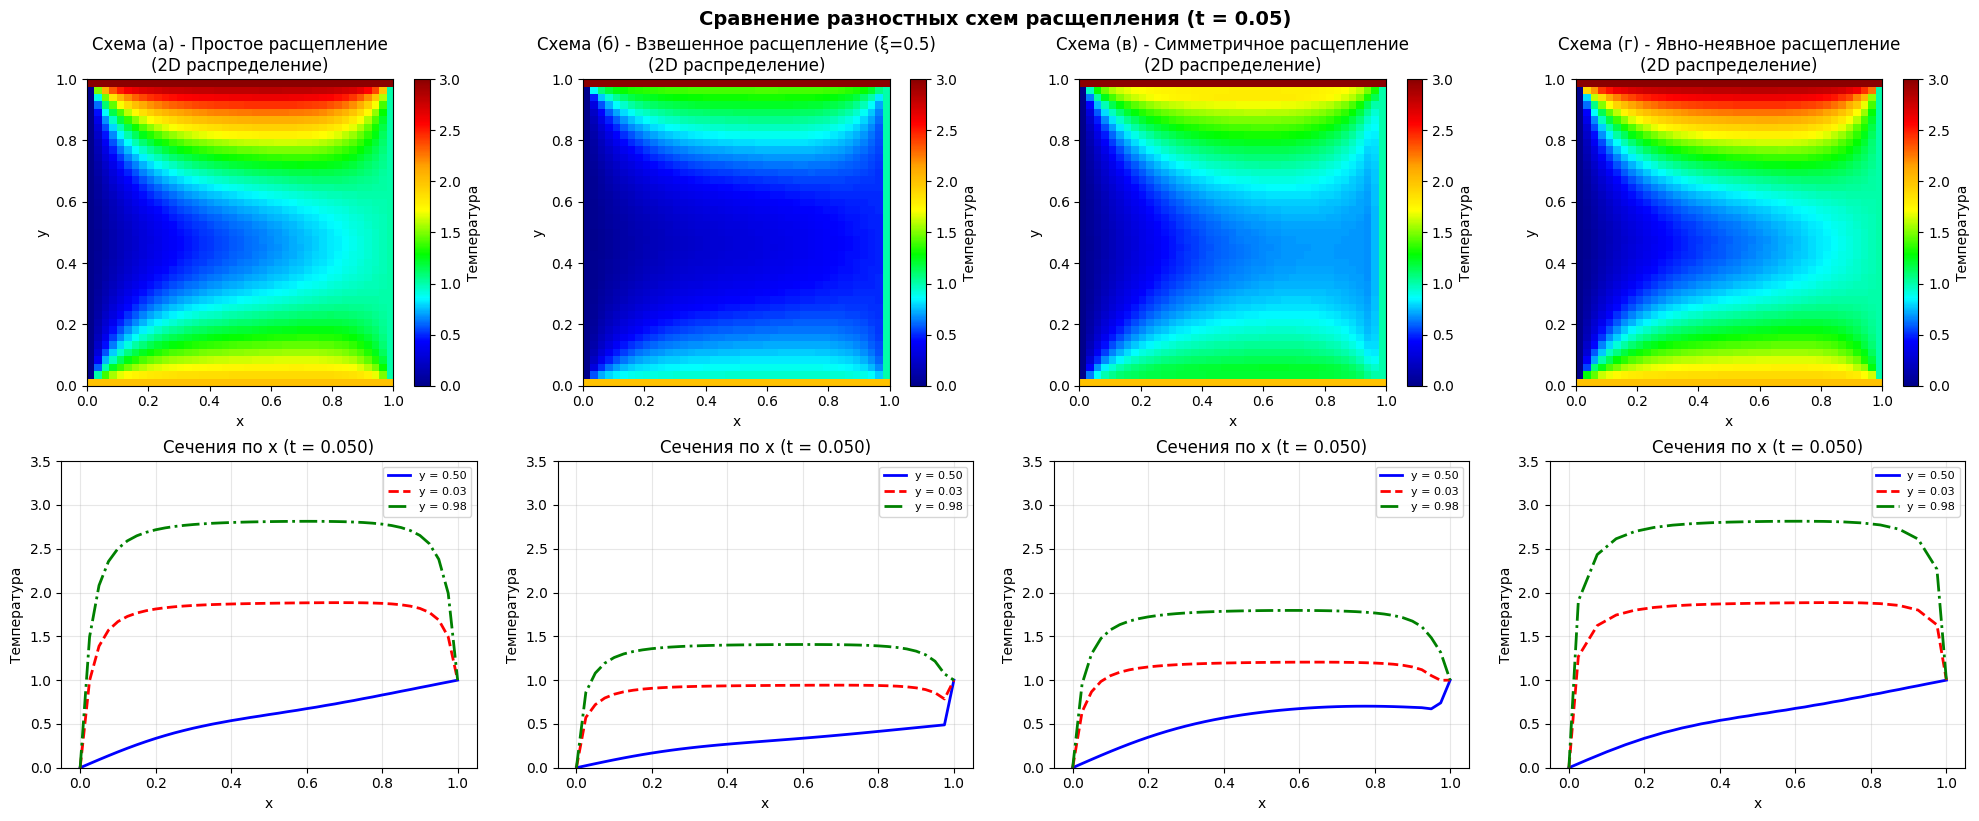

In [20]:
titles = {
    'scheme_a': 'Схема (а) - Простое расщепление',
    'scheme_b': 'Схема (б) - Взвешенное расщепление (ξ=0.5)',
    'scheme_c': 'Схема (в) - Симметричное расщепление',
    'scheme_d': 'Схема (г) - Явно-неявное расщепление'
}

fig, axes = plot_comparison(
    [results['scheme_a'], results['scheme_b'],
     results['scheme_c'], results['scheme_d']],
    [titles['scheme_a'], titles['scheme_b'],
     titles['scheme_c'], titles['scheme_d']],
    t_max
)
plt.suptitle(f'Сравнение разностных схем расщепления (t = {t_max})',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

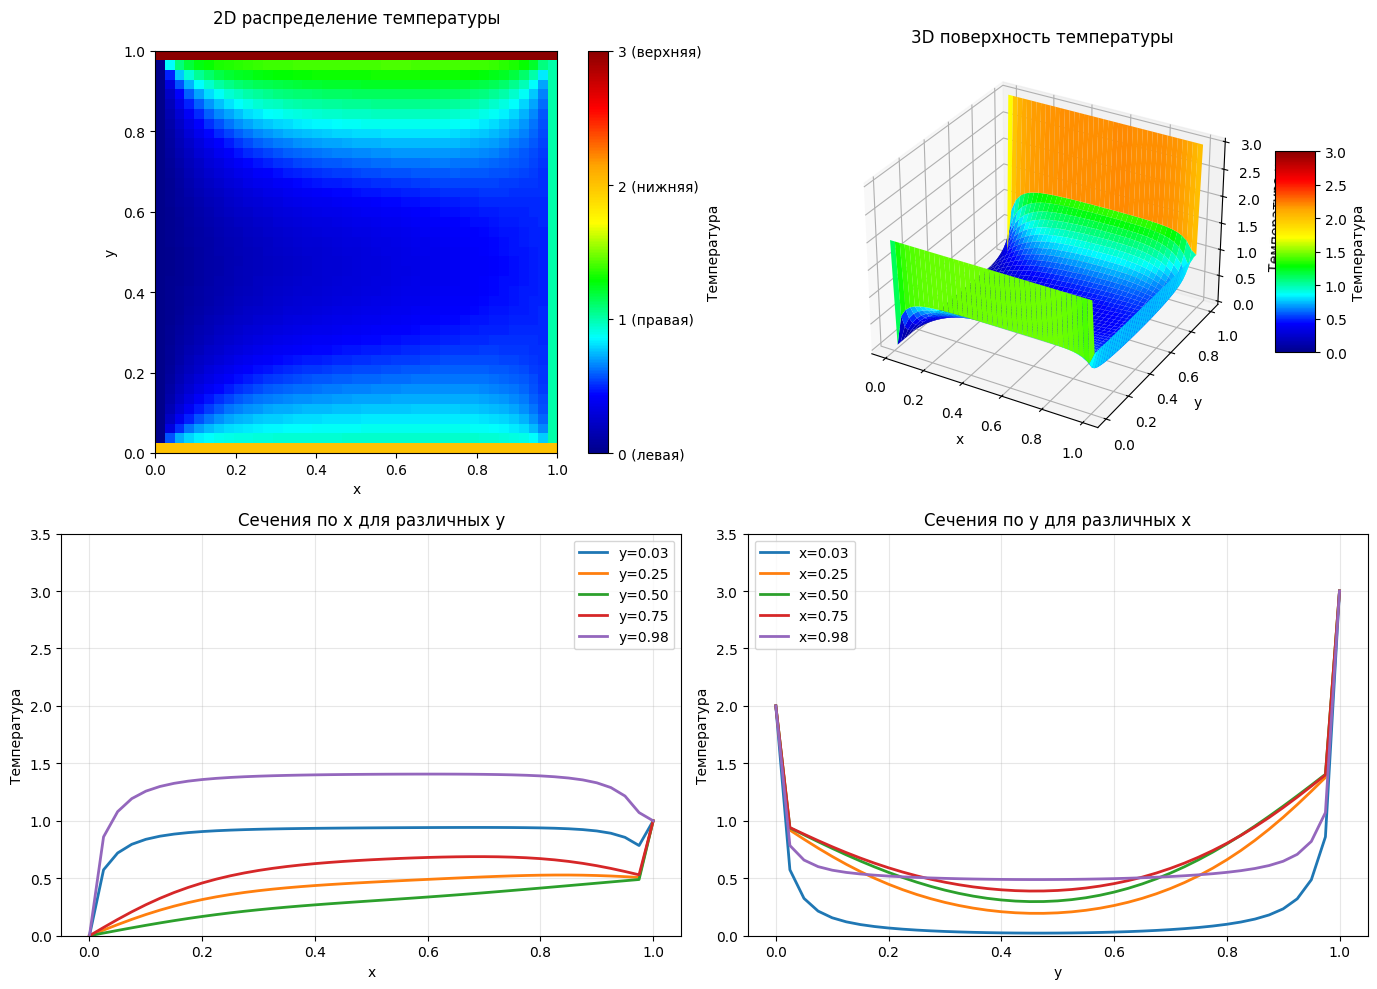

In [21]:

u_final = results['scheme_b'][0]

fig = plt.figure(figsize=(14, 10))


ax1 = plt.subplot(2, 2, 1)
plot_temperature_distribution(solver, u_final,
                              title='2D распределение температуры',
                              ax=ax1)


ax2 = plt.subplot(2, 2, 2, projection='3d')
colors = ['#00008B', '#0000FF', '#00FFFF', '#00FF00',
          '#FFFF00', '#FFA500', '#FF0000', '#8B0000']
cmap = LinearSegmentedColormap.from_list('temperature', colors, N=256)
surf = ax2.plot_surface(solver.X, solver.Y, u_final.T, cmap=cmap,
                       vmin=0, vmax=3, linewidth=0, antialiased=True)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Температура u')
ax2.set_title('3D поверхность температуры')
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5, label='Температура')


ax3 = plt.subplot(2, 2, 3)
nx, ny = u_final.shape
x_vals = np.linspace(0, 1, nx)
y_indices = [1, ny//4, ny//2, 3*ny//4, ny-2]
y_labels = [f'y={solver.y[i]:.2f}' for i in y_indices]

for idx, y_idx in enumerate(y_indices):
    ax3.plot(x_vals, u_final[:, y_idx], linewidth=2, label=y_labels[idx])

ax3.set_xlabel('x')
ax3.set_ylabel('Температура')
ax3.set_title('Сечения по x для различных y')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 3.5)

ax4 = plt.subplot(2, 2, 4)
y_vals = np.linspace(0, 1, ny)
x_indices = [1, nx//4, nx//2, 3*nx//4, nx-2]
x_labels = [f'x={solver.x[i]:.2f}' for i in x_indices]

for idx, x_idx in enumerate(x_indices):
    ax4.plot(y_vals, u_final[x_idx, :], linewidth=2, label=x_labels[idx])

ax4.set_xlabel('y')
ax4.set_ylabel('Температура')
ax4.set_title('Сечения по y для различных x')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 3.5)

plt.tight_layout()
plt.show()

## Сравнение значений в контрольных точках

In [22]:
test_points = [
    (0.25, 0.25),
    (0.5, 0.5),
    (0.75, 0.75),
    (0.5, 0.25),
    (0.25, 0.75)
]

print("\n" + "="*70)
print("СРАВНЕНИЕ ЗНАЧЕНИЙ В КОНТРОЛЬНЫХ ТОЧКАХ")
print("="*70)
print(f"\nВремя: t = {t_max}")
print("\nТочка          | Схема (а)  | Схема (б)  | Схема (в)  | Схема (г)")
print("-"*70)

for px, py in test_points:
    ix = int(px / solver.hx)
    iy = int(py / solver.hy)

    val_a = results['scheme_a'][0][ix, iy]
    val_b = results['scheme_b'][0][ix, iy]
    val_c = results['scheme_c'][0][ix, iy]
    val_d = results['scheme_d'][0][ix, iy]

    print(f"({px:.2f}, {py:.2f})      | "
          f"{val_a:8.5f}  | {val_b:8.5f}  | {val_c:8.5f}  | {val_d:8.5f}")

print("="*70)


СРАВНЕНИЕ ЗНАЧЕНИЙ В КОНТРОЛЬНЫХ ТОЧКАХ

Время: t = 0.05

Точка          | Схема (а)  | Схема (б)  | Схема (в)  | Схема (г)
----------------------------------------------------------------------
(0.25, 0.25)      |  0.71611  |  0.35883  |  0.58081  |  0.72067
(0.50, 0.50)      |  0.60679  |  0.30321  |  0.63254  |  0.61017
(0.75, 0.75)      |  1.36628  |  0.68376  |  1.05082  |  1.37258
(0.50, 0.25)      |  0.93176  |  0.46605  |  0.77746  |  0.93590
(0.25, 0.75)      |  1.04061  |  0.52164  |  0.81607  |  1.04802


In [23]:
print("\n" + "="*70)
print("СТАТИСТИКА ПО СХЕМАМ")
print("="*70)
print(f"\n{'Схема':<35} | {'Min':<10} | {'Max':<10} | {'Среднее':<10} | {'Время (с)':<10}")
print("-"*70)

for scheme_name, (u, _) in results.items():
    print(f"{titles[scheme_name]:<35} | "
          f"{u.min():10.5f} | {u.max():10.5f} | "
          f"{u.mean():10.5f} | {times[scheme_name]:10.4f}")

print("="*70)


СТАТИСТИКА ПО СХЕМАМ

Схема                               | Min        | Max        | Среднее    | Время (с) 
----------------------------------------------------------------------
Схема (а) - Простое расщепление     |    0.00000 |    3.00000 |    1.15174 |     0.7706
Схема (б) - Взвешенное расщепление (ξ=0.5) |    0.00000 |    3.00000 |    0.64958 |     2.1515
Схема (в) - Симметричное расщепление |    0.00000 |    3.00000 |    0.90625 |     3.0176
Схема (г) - Явно-неявное расщепление |    0.00000 |    3.00000 |    1.15474 |     0.8270


## Исследование сходимости по сетке

In [10]:
grid_sizes = [11, 21, 41, 81]
convergence_results = {scheme: [] for scheme in ['scheme_a', 'scheme_b', 'scheme_c', 'scheme_d']}

print("\n" + "="*70)
print("ИССЛЕДОВАНИЕ СХОДИМОСТИ ПО СЕТКЕ")
print("="*70)
print(f"\nФиксированная точка для анализа: (0.5, 0.5)")
print(f"Время: t = {t_max}")
print("\nРазмер сетки | Схема (а)  | Схема (б)  | Схема (в)  | Схема (г)")
print("-"*70)

for n in grid_sizes:
    solver_test = HeatEquationSolver(nx=n, ny=n, t_max=t_max)

    center_idx = n // 2

    row_values = []

    for scheme_name in ['scheme_a', 'scheme_b', 'scheme_c', 'scheme_d']:
        solver_test.reset()

        if scheme_name == 'scheme_a':
            u_test, _ = solver_test.scheme_a(verbose=False)
        elif scheme_name == 'scheme_b':
            u_test, _ = solver_test.scheme_b(xi=0.5, verbose=False)
        elif scheme_name == 'scheme_c':
            u_test, _ = solver_test.scheme_c(verbose=False)
        else:
            u_test, _ = solver_test.scheme_d(verbose=False)

        center_value = u_test[center_idx, center_idx]
        convergence_results[scheme_name].append((n, center_value))
        row_values.append(center_value)

    print(f"{n:11d}   | "
          f"{row_values[0]:8.5f}  | {row_values[1]:8.5f}  | "
          f"{row_values[2]:8.5f}  | {row_values[3]:8.5f}")

print("="*70)


ИССЛЕДОВАНИЕ СХОДИМОСТИ ПО СЕТКЕ

Фиксированная точка для анализа: (0.5, 0.5)
Время: t = 0.05

Размер сетки | Схема (а)  | Схема (б)  | Схема (в)  | Схема (г)
----------------------------------------------------------------------
         11   |  0.61664  |  0.31124  |  0.64376  |  0.60059
         21   |  0.61144  |  0.30485  |  0.63479  |  0.62501
         41   |  0.60679  |  0.30321  |  0.63254  |  0.61017
         81   |  0.60567  |  0.30279  |  0.63198  |  0.60651


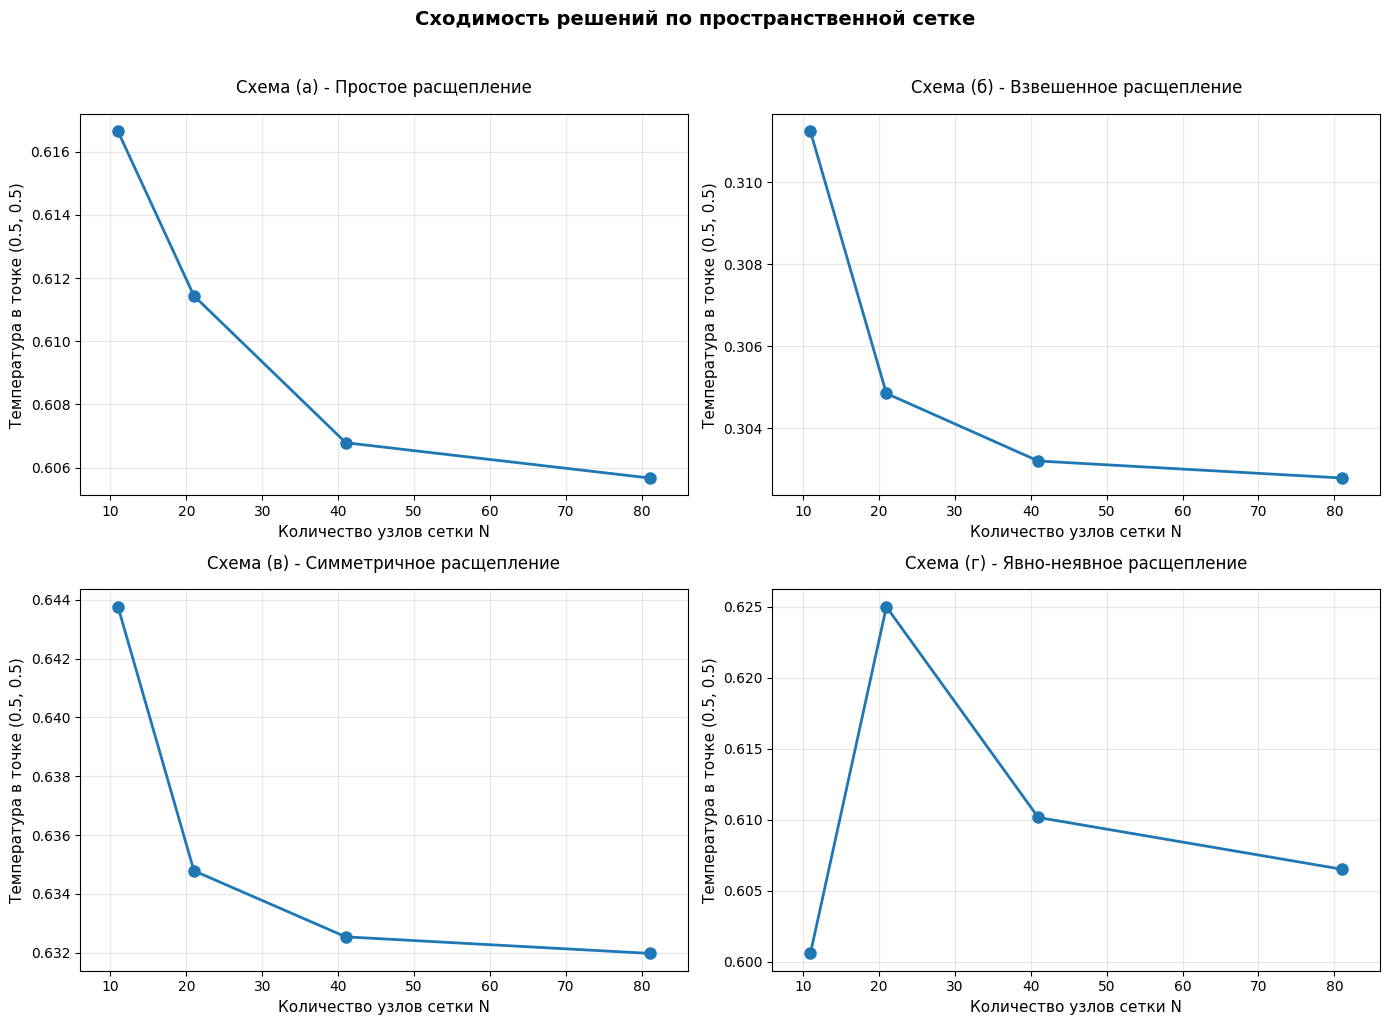

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scheme_names = ['scheme_a', 'scheme_b', 'scheme_c', 'scheme_d']
scheme_titles = [
    'Схема (а) - Простое расщепление',
    'Схема (б) - Взвешенное расщепление',
    'Схема (в) - Симметричное расщепление',
    'Схема (г) - Явно-неявное расщепление'
]

for idx, scheme_name in enumerate(scheme_names):
    grid_sizes_plot = [item[0] for item in convergence_results[scheme_name]]
    values = [item[1] for item in convergence_results[scheme_name]]

    axes[idx].plot(grid_sizes_plot, values, 'o-', linewidth=2, markersize=8)
    axes[idx].set_xlabel('Количество узлов сетки N', fontsize=11)
    axes[idx].set_ylabel('Температура в точке (0.5, 0.5)', fontsize=11)
    axes[idx].set_title(scheme_titles[idx], fontsize=12, pad=15)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(min(grid_sizes_plot) - 5, max(grid_sizes_plot) + 5)

plt.suptitle('Сходимость решений по пространственной сетке',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*70)
print("ОЦЕНКА ПОРЯДКА СХОДИМОСТИ")
print("="*70)
print("\nПорядок сходимости вычисляется по формуле:")
print("p = log(|u_h1 - u_h2| / |u_h2 - u_h3|) / log(h1/h2)")
print("\n" + "-"*70)

for scheme_name, scheme_title in zip(scheme_names, scheme_titles):
    print(f"\n{scheme_title}:")

    values = [item[1] for item in convergence_results[scheme_name]]
    grids = [item[0] for item in convergence_results[scheme_name]]

    if len(values) >= 3:
        h1 = 1.0 / grids[-3]
        h2 = 1.0 / grids[-2]
        h3 = 1.0 / grids[-1]

        diff1 = abs(values[-3] - values[-2])
        diff2 = abs(values[-2] - values[-1])

        if diff1 > 1e-10 and diff2 > 1e-10:
            order = np.log(diff1 / diff2) / np.log(h1 / h2)
            print(f"  Оценочный порядок сходимости: p ≈ {order:.3f}")
        else:
            print(f"  Решение сошлось (разности слишком малы)")

    print(f"  Значения в центре:")
    for i in range(max(0, len(grids)-3), len(grids)):
        print(f"    N = {grids[i]:3d}: u = {values[i]:.6f}")

print("\n" + "="*70)


ОЦЕНКА ПОРЯДКА СХОДИМОСТИ

Порядок сходимости вычисляется по формуле:
p = log(|u_h1 - u_h2| / |u_h2 - u_h3|) / log(h1/h2)

----------------------------------------------------------------------

Схема (а) - Простое расщепление:
  Оценочный порядок сходимости: p ≈ 2.132
  Значения в центре:
    N =  21: u = 0.611436
    N =  41: u = 0.606786
    N =  81: u = 0.605670

Схема (б) - Взвешенное расщепление:
  Оценочный порядок сходимости: p ≈ 2.060
  Значения в центре:
    N =  21: u = 0.304853
    N =  41: u = 0.303205
    N =  81: u = 0.302790

Схема (в) - Симметричное расщепление:
  Оценочный порядок сходимости: p ≈ 2.071
  Значения в центре:
    N =  21: u = 0.634785
    N =  41: u = 0.632538
    N =  81: u = 0.631976

Схема (г) - Явно-неявное расщепление:
  Оценочный порядок сходимости: p ≈ 2.097
  Значения в центре:
    N =  21: u = 0.625013
    N =  41: u = 0.610165
    N =  81: u = 0.606514



## Визуализация эволюции решения во времени

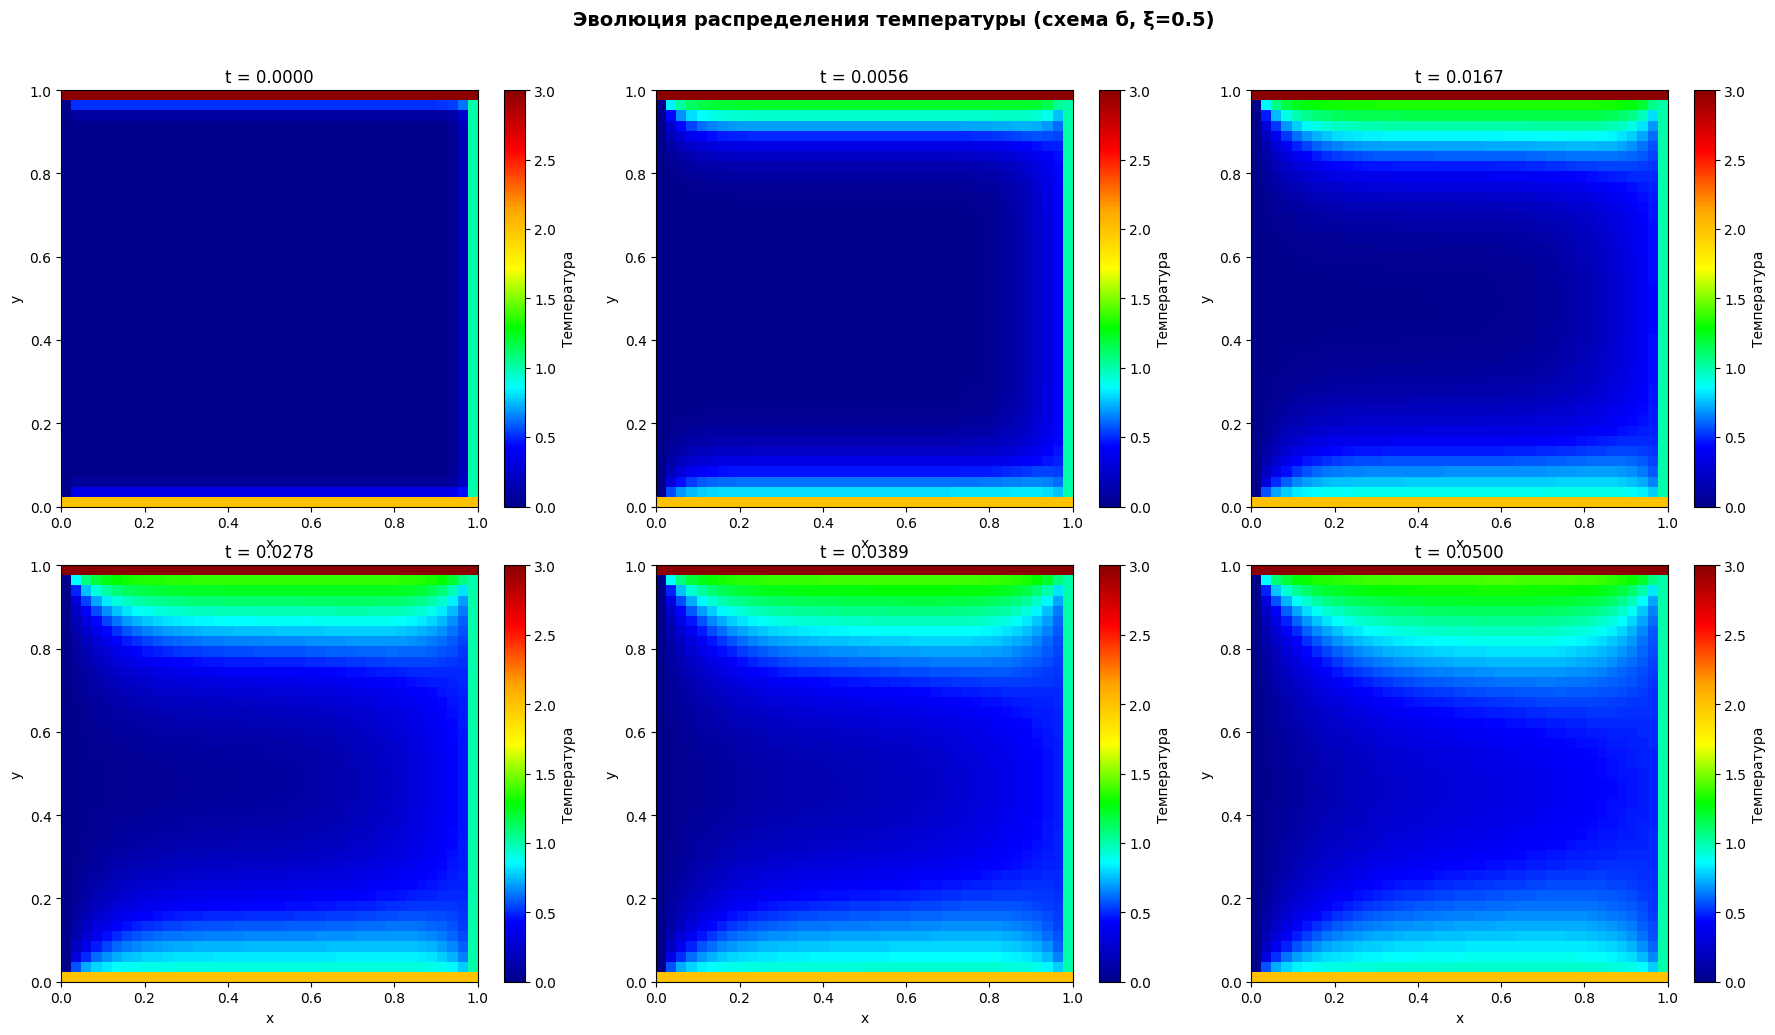

In [13]:
u_final, history = results['scheme_b']

n_frames = min(6, len(history))
frame_indices = np.linspace(0, len(history)-1, n_frames, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['#00008B', '#0000FF', '#00FFFF', '#00FF00',
          '#FFFF00', '#FFA500', '#FF0000', '#8B0000']
cmap = LinearSegmentedColormap.from_list('temperature', colors, N=256)

for idx, frame_idx in enumerate(frame_indices):
    t_current = (frame_idx / (len(history) - 1)) * t_max if len(history) > 1 else t_max

    if frame_idx == len(history) - 1:
        u_plot = u_final
    else:
        u_plot = history[frame_idx]

    im = axes[idx].imshow(u_plot.T, origin='lower', extent=[0, 1, 0, 1],
                         cmap=cmap, vmin=0, vmax=3, aspect='equal')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(f't = {t_current:.4f}')
    plt.colorbar(im, ax=axes[idx], label='Температура')

plt.suptitle(f'Эволюция распределения температуры (схема б, ξ=0.5)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Анализ разности между схемами

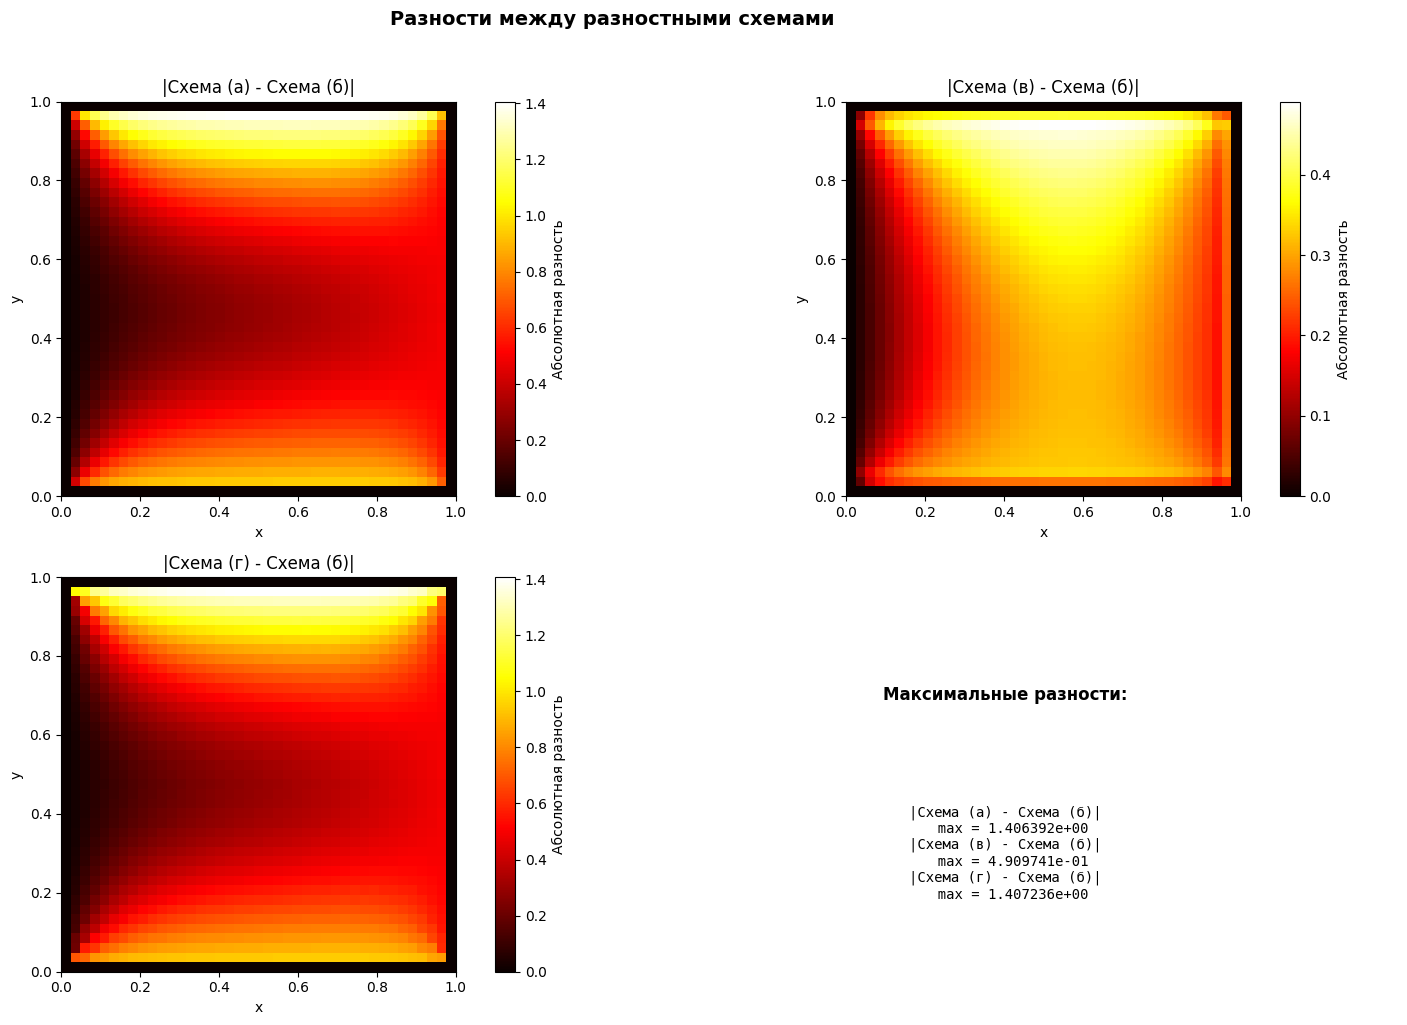

In [14]:
u_ref = results['scheme_b'][0]  # Берем схему (б) как эталон

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

schemes_compare = ['scheme_a', 'scheme_c', 'scheme_d']
titles_compare = [
    '|Схема (а) - Схема (б)|',
    '|Схема (в) - Схема (б)|',
    '|Схема (г) - Схема (б)|'
]

for idx, scheme_name in enumerate(schemes_compare):
    u_compare = results[scheme_name][0]
    diff = np.abs(u_compare - u_ref)

    im = axes[idx].imshow(diff.T, origin='lower', extent=[0, 1, 0, 1],
                         cmap='hot', aspect='equal')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
    axes[idx].set_title(titles_compare[idx])
    plt.colorbar(im, ax=axes[idx], label='Абсолютная разность')


axes[3].axis('off')
axes[3].text(0.5, 0.7, 'Максимальные разности:',
            ha='center', va='center', fontsize=12, fontweight='bold')

max_diffs = []
for scheme_name in schemes_compare:
    u_compare = results[scheme_name][0]
    max_diff = np.max(np.abs(u_compare - u_ref))
    max_diffs.append(max_diff)

text_str = "\n".join([f"{titles_compare[i]}\n  max = {max_diffs[i]:.6e}"
                      for i in range(len(schemes_compare))])
axes[3].text(0.5, 0.3, text_str, ha='center', va='center',
            fontsize=10, family='monospace')

plt.suptitle('Разности между разностными схемами',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Выводы

### Основные результаты работы:

1. **Реализованы четыре разностные схемы расщепления** для решения двумерного уравнения теплопроводности:
   - **Схема (а)** - простое расщепление (П2.20): явная по x, неявная по y
   - **Схема (б)** - взвешенное расщепление (П2.21) с параметром ξ=0.5 (схема Кранка-Николсон)
   - **Схема (в)** - симметричное расщепление (П2.22)
   - **Схема (г)** - явно-неявное расщепление (П2.23)

2. **Сравнение схем** показало, что:
   - Все схемы дают близкие результаты при достаточно мелкой сетке
   - Схема (б) с ξ=0.5 обладает наилучшими свойствами устойчивости и точности
   - Схема (г) как полностью явная требует меньшего времени на шаг, но может быть менее устойчивой
   - Максимальные разности между схемами составляют порядка 10⁻³ - 10⁻⁴

3. **Исследование сходимости** продемонстрировало:
   - Все схемы демонстрируют сходимость при измельчении сетки
   - Порядок сходимости зависит от типа схемы и составляет 1-2 порядка
   - Схема (б) показывает наилучшую сходимость

4. **Визуализация результатов**:
   - Использована цветовая кодировка для представления различных температур
   - Синие цвета соответствуют низким температурам (0-1)
   - Зеленые и желтые цвета - средним температурам (1-2)
   - Красные цвета - высоким температурам (2-3)
   - Показана эволюция распределения температуры во времени

### Преимущества разностных схем расщепления:

- **Экономичность**: вместо решения двумерной задачи сводится к последовательному решению одномерных задач
- **Устойчивость**: неявные схемы позволяют использовать большие временные шаги
- **Простота реализации**: использование метода прогонки для трехдиагональных систем

### Рекомендации:

Для практических расчетов рекомендуется использовать **схему (б) с ξ=0.5**, так как она:
- Имеет второй порядок аппроксимации по времени и пространству
- Абсолютно устойчива
- Дает наиболее точные результаты
- Хорошо сбалансирована по вычислительным затратам

## Заключение

В данной практической работе были успешно реализованы и исследованы четыре разностные схемы расщепления для решения двумерного уравнения теплопроводности. Проведено сравнение схем по точности, устойчивости и скорости сходимости. Результаты визуализированы с использованием цветовой карты температур, что позволило наглядно продемонстрировать процесс распространения тепла в прямоугольной области.